# 19.3 支持向量机的应用

### 1. 支持向量机的分类问题

在支持向量机分类问题的模型中，有两个重要参数需要选择，一个是软间隔惩罚系数 $ C $，另一个是核函数的类型。核函数有如下几种：①线性函数，②多项式函数，③径向基函数，④Sigmoid函数。  

网格搜索法可以用来寻找合适的参数，即尝试所有可能的参数组合。为了进行网格搜索，可以借助scikit - learn提供的GridSearchCV类.使用这个类时，我们可以通过字典来提供分类器或回归器的类型对象.字典的键就是我们将要调整的参数，而字典的值就是需要尝试的参数值的相应列表。  



`sklearn.svm`子模块中的`LinearSVC`以及`SVC`类可以实现支持向量分类算法.其中SVC的基本语法和参数含义如下：  

```python
SVC(C = 1.0, kernel='rbf', degree = 3, gamma='auto_deprecated', coef0 = 0.0, shrinking = True, probability = False, tol = 0.001, cache_size = 200, class_weight = None, verbose = False, max_iter = - 1, decision_function_shape='ovr', random_state = None)
```  

- `C`：用于指定目标函数中松弛因子的惩罚系数值，默认为1。  
- `kernel`：用于指定模型的核函数，该参数如果为`'linear'`，就表示线性核函数；如果为`'poly'`，就表示多项式核函数，核函数中的 $ r $ 和 $ p $ 值分别使用degree参数和gamma参数指定；如果为`'sigmoid'`，表示Sigmoid核函数，核函数中的 $ r $ 参数值需要通过gamma参数指定；如果为`'precomputed'`，表示计算一个核矩阵。  
- `degree`：用于指定多项式核函数中的 $ p $ 参数值。  
- `gamma`：用于指定多项式核函数或Sigmoid核函数中的 $ r $ 参数值。  
- `coef0`：用于指定多项式核函数或Sigmoid核函数中的参数值。  
- `shrinking`：bool类型参数，是否采用启发式收缩方式，默认为True。  
- `probability`：bool类型参数，是否需要对样本所属类别进行概率计算，默认为False。  
- `tol`：用于指定SVM模型迭代的收敛条件，默认为0.001。  
- `cache_size`：用于指定核函数运算的内存空间，默认为200M。  
- `class_weight`：用于指定因变量类别的权重。  
- `verbose`：bool类型参数，是否输出模型迭代过程的信息，默认为0，表示不输出。  
- `decision_function_shape`：用于指定SVM模型的决策函数形状。  
- `random_state`：用于指定随机数生成器的种子。  


**例 19.1（续例 11.14）** 对 Iris 数据集的三类花卉进行分类.  

**解**  使用支持向量机进行分类，在 150 个已知样本点中，只有一个误判，预测的准确率为 99.33%.  

In [1]:
import numpy as np
from sklearn import datasets, svm, metrics
from sklearn.model_selection import GridSearchCV

iris = datasets.load_iris()
x = iris.data
y = iris.target
parameters = {'kernel': ('linear', 'rbf'), 'C': [1, 10, 15]}
svc = svm.SVC(gamma='scale')
clf = GridSearchCV(svc, parameters, cv=5)  # cv(cross validation)为交叉验证参数，为5折
clf.fit(x, y)
print(f"最佳的参数值: {clf.best_params_}")
print(f"score: clf.score(x, y)")

yh = clf.predict(x)
print(yh)  # 显示分类结果
print(f"预测准确率: {metrics.accuracy_score(y, yh)}")
print(f"误判的样本点为: {np.where(yh!=y)[0] + 1}")

最佳的参数值: {'C': 1, 'kernel': 'linear'}
score: clf.score(x, y)
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 2 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2]
预测准确率: 0.9933333333333333
误判的样本点为: [84]


In [14]:
import pandas as pd

iris_1 = pd.DataFrame(iris.data, columns=['萼片长度', '萼片宽度', '花瓣长度', '花瓣宽度'])
iris_2 = pd.DataFrame(iris.target, columns=['类别'])
combined_df = pd.concat([iris_1, iris_2], axis=1)
combined_df.to_excel("iris.xlsx", index=False)
combined_df

,萼片长度,萼片宽度,花瓣长度,花瓣宽度,类别
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2


In [12]:
from sklearn import datasets, svm
from sklearn.model_selection import GridSearchCV
import numpy as np

iris = datasets.load_iris()
x = iris.data
y = iris.target
clf = svm.LinearSVC(C=1, max_iter=10000)
clf.fit(x, y)
yh = clf.predict(x)
print(yh)
print(f"预测的准确率: {clf.score(x, y)}")

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 1 1 1
 1 1 1 1 1 1 1 1 1 2 2 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 1 2 2 2 1 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2]
预测的准确率: 0.9666666666666667


### 2. 支持向量分析

`sklearn.svm` 子模块中的 `LinearSVM` 以及 `SVR` 类可以实现支持向量回归算法。其中 SVR 的基本语法和参数含义如下：  

```python
SVR(kernel='rbf', degree=3, gamma='auto_deprecated', coef0=0.0, tol=0.001, C=1.0, epsilon=0.1, shrinking=True, cache_size=200, verbose=False, max_iter=-1)
```  

各参数说明：  
- `kernel`：指定核函数，如 `'linear'`（线性 ）、`'poly'`（多项式 ）、`'rbf'`（径向基，默认 ）等，决定数据映射方式。  
- `degree`：多项式核的次数 $ p $，仅 `kernel='poly'` 时生效。  
- `gamma`：多项式/Sigmoid 核的参数，影响核函数形状；`rbf` 核下控制 “高斯分布宽度”。  
- `coef0`：多项式/Sigmoid 核的偏移参数，调整核函数形状。  
- `tol`：模型迭代收敛条件，默认 0.001。  
- `C`：软间隔惩罚系数，平衡 “间隔最大化” 与 “误分类（回归中是误差 ）最小化”，`C` 越大对误差惩罚越重。  
- `epsilon`：不敏感损失函数的 $ \varepsilon $，线性 SVR 默认 0，非线性默认 0.1，控制误差容忍范围。  
- `shrinking`：是否用启发式收缩加速，默认 `True`。  
- `cache_size`：核函数运算内存，默认 200M。  
- `verbose`：是否输出迭代信息，默认 `False`（不输出 ）。  
- `max_iter`：最大迭代次数，`-1` 表示无限制。  


**例 19.2** 用模拟数据 $ x_i = i\ (i = 0,1,\cdots,199) $，$ y_i = \sin(x_i) + 3 + \varepsilon $（$ \varepsilon \sim U(-1,1) $ 是 $(-1,1)$ 均匀分布随机数 ），做支持向量机回归分析。  

**解**  调用 Python 函数（用 `sklearn.svm.SVR` ），画出模拟数据点与预测值（如图 19.3 ），模型残差平方和为 15.0664 ，实现对非线性数据的回归拟合。核心流程一般是：构造数据、实例化 SVR 模型、训练、预测、计算残差等，示例伪代码：  
```python
from sklearn.svm import SVR
import numpy as np
# 构造数据
x = np.arange(200).reshape(-1, 1)
epsilon = np.random.uniform(-1, 1, 200)
y = np.sin(x) + 3 + epsilon  
# 建模、训练、预测
svr = SVR()
svr.fit(x, y)
y_pred = svr.predict(x)
# 计算残差平方和等评估指标...
```  
通过 SVR 拟合带噪声的正弦曲线数据，展示支持向量回归解决非线性回归问题的能力。

SVR(gamma='auto')
原始数据与预测值前十五个值对比: 
2.749080237694725 2.849132094275757
4.742899597627729 4.103459941026795
4.373285310448492 4.273204617285177
3.3384369764539406 3.237953435027042
1.5552347855769446 1.7918368543017607
1.3530647660092667 1.4528895292974713
1.836751726137473 2.035739624887464
4.389338890268659 3.7724644441077264
4.1915882701098 4.091238503488992
3.8282636408338475 3.7282591038035564
1.4971478777022353 2.402299451066899
2.9398294977732853 2.8401174008217387
3.1283123636004087 3.0282504303822106
2.8448452581831933 2.945116587851062
3.3542572901090715 3.2538394388907887
score: 0.9042879631696237
残差平方和: 16.68810060010277


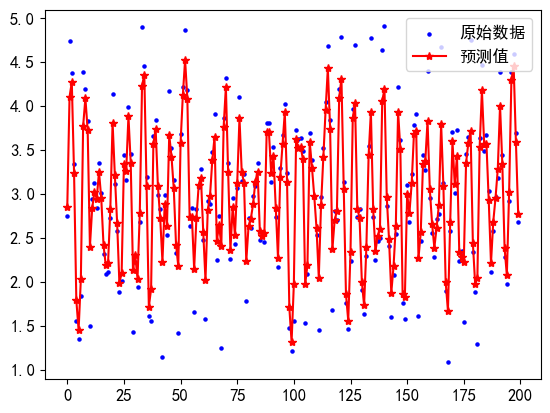

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVR

np.random.seed(42)
x = np.arange(200).reshape(-1, 1)  # reshape(-1, 1)列向量
y = (np.sin(x) + 3 + np.random.uniform(-1, 1, (200, 1))).ravel()  # ravel()将多维数组展平为一维数组

model = SVR(gamma='auto')
print(model)

model.fit(x, y)  # 列向量训练
pred_y = model.predict(x)
print(f"原始数据与预测值前十五个值对比: ")
for i in range(15):
    print(y[i], pred_y[i])
    
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['font.size'] = 12

plt.scatter(x, y, s=5, color="blue", label="原始数据")
plt.plot(x, pred_y, '-r*', lw=1.5, label="预测值")
plt.legend(loc=1)

score=model.score(x, y)
print(f"score: {score}")

ss = ((y - pred_y)**2).sum()  # 残差平方和
print(f"残差平方和: {ss}")

plt.show()